# Bài thực hành chương 1

Notebook này giải các yêu cầu chương 1 bằng OpenCV, Pillow, NumPy và Matplotlib.

**Cách dùng nhanh:** chạy lần lượt từng cell từ trên xuống. Notebook dùng ảnh có sẵn trong `IMAGE_PATH`; nếu muốn dùng ảnh riêng, đổi biến này trong phần cấu hình.

## Câu 1. Cài đặt các thư viện OpenCV và Pillow

**Input:** môi trường Python/Jupyter.

**Output:** cài đặt và kiểm tra phiên bản thư viện.

**Thuật toán:** dùng `pip` cài các gói cần thiết, sau đó import để kiểm tra.

In [1]:
# !pip install opencv-python pillow matplotlib numpy
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


## Cấu hình ảnh đầu vào

Đổi `IMAGE_PATH` thành đường dẫn ảnh của bạn, ví dụ: `r'D:/anh/test.jpg'`. Nếu tệp không tồn tại, notebook sẽ báo lỗi để bạn kiểm tra lại đường dẫn.

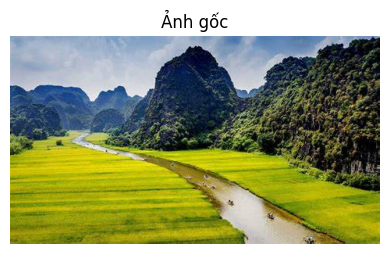

In [2]:
IMAGE_PATH = 'image/sample_chapter_1.jpg'
OUTPUT_DIR = Path('outputs_chapter_1')
OUTPUT_DIR.mkdir(exist_ok=True)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def show_images(items, cols=None):
    cols = cols or len(items)
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
    for ax, (title, img) in zip(axes.ravel(), items):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')
    for ax in axes.ravel()[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images([('Ảnh gốc', image_rgb)])


## Câu 2. Đọc, hiển thị và lưu ảnh

**Input:** một ảnh bất kỳ từ máy tính.

**Output:** ảnh được hiển thị và ảnh đã lưu lại với định dạng khác.

**Thuật toán:**
1. Dùng `cv2.imread` đọc ảnh theo định dạng BGR.
2. Đổi BGR sang RGB để hiển thị đúng màu bằng Matplotlib.
3. Dùng `cv2.imwrite` hoặc Pillow để lưu ảnh sang định dạng khác.

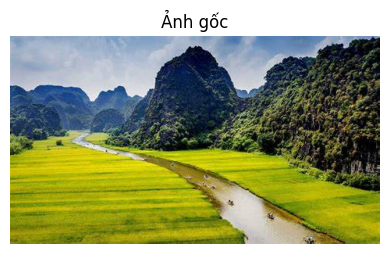

In [3]:
show_images([('Ảnh gốc', image_rgb)])

cv2.imwrite(str(OUTPUT_DIR / 'cau_2_anh_luu_lai.png'), image_bgr)
Image.fromarray(image_rgb).save(OUTPUT_DIR / 'cau_2_anh_luu_lai.jpg', quality=95)


## Câu 3. Chuyển đổi không gian màu

**Input:** ảnh màu RGB/BGR.

**Output:** ảnh grayscale, HSV và LAB.

**Thuật toán:** dùng `cv2.cvtColor` chuyển từng không gian màu. Ảnh HSV/LAB được hiển thị theo từng kênh để dễ quan sát.

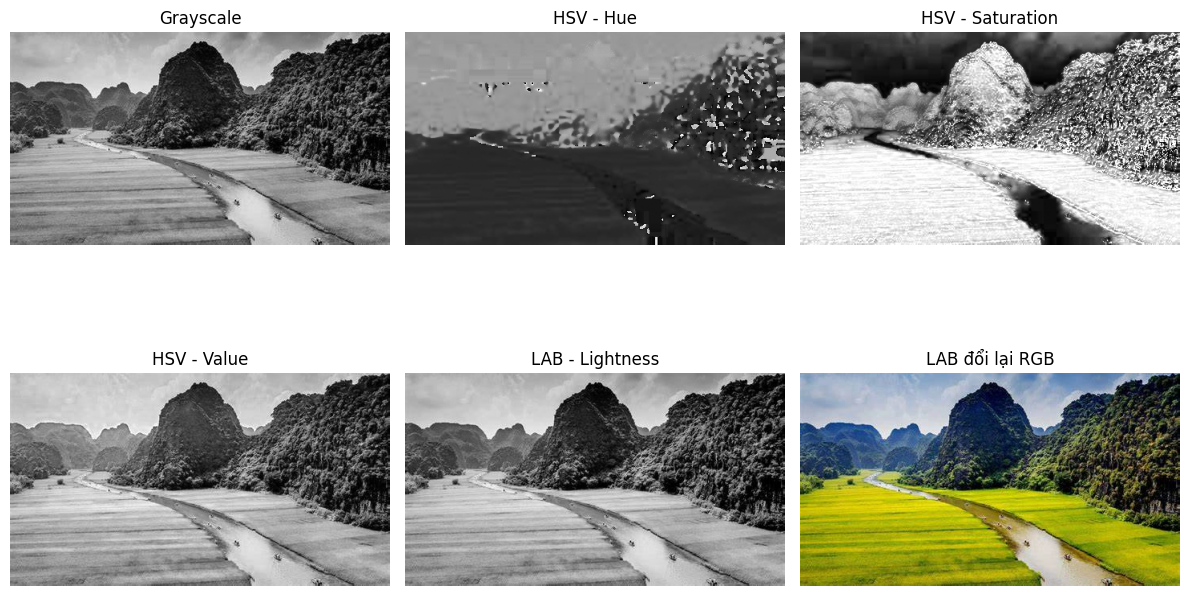

In [4]:
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)

cv2.imwrite(str(OUTPUT_DIR / 'cau_3_grayscale.png'), gray)
cv2.imwrite(str(OUTPUT_DIR / 'cau_3_hsv.png'), hsv)
cv2.imwrite(str(OUTPUT_DIR / 'cau_3_lab.png'), lab)

show_images([
    ('Grayscale', gray),
    ('HSV - Hue', hsv[:, :, 0]),
    ('HSV - Saturation', hsv[:, :, 1]),
    ('HSV - Value', hsv[:, :, 2]),
    ('LAB - Lightness', lab[:, :, 0]),
    ('LAB đổi lại RGB', cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)),
], cols=3)


## Câu 4. Cắt xén và thay đổi kích thước

**Input:** ảnh gốc.

**Output:** vùng ảnh đã cắt, ảnh resize theo tỷ lệ và ảnh resize theo kích thước cố định.

**Thuật toán:**
1. Cắt ảnh bằng slicing `image[y1:y2, x1:x2]`.
2. Resize theo tỷ lệ bằng cách nhân chiều rộng/cao với hệ số.
3. Resize cố định bằng kích thước `(width, height)`.

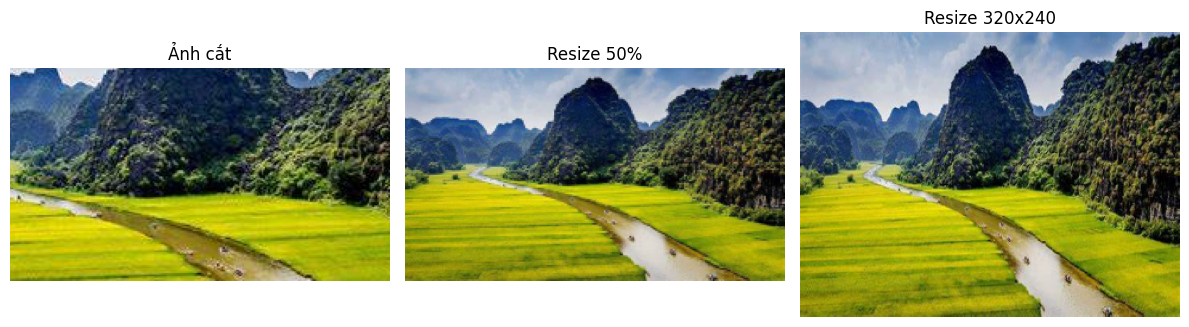

In [5]:
height, width = image_bgr.shape[:2]
cropped = image_bgr[height // 4:3 * height // 4, width // 4:3 * width // 4]
resized_by_scale = cv2.resize(image_bgr, None, fx=0.5, fy=0.5)
resized_fixed = cv2.resize(image_bgr, (320, 240))

cv2.imwrite(str(OUTPUT_DIR / 'cau_4_cat_vung_trung_tam.png'), cropped)
cv2.imwrite(str(OUTPUT_DIR / 'cau_4_resize_50_percent.png'), resized_by_scale)
cv2.imwrite(str(OUTPUT_DIR / 'cau_4_resize_320x240.png'), resized_fixed)

show_images([
    ('Ảnh cắt', cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)),
    ('Resize 50%', cv2.cvtColor(resized_by_scale, cv2.COLOR_BGR2RGB)),
    ('Resize 320x240', cv2.cvtColor(resized_fixed, cv2.COLOR_BGR2RGB)),
])


## Câu 5. Vẽ hình cơ bản và thêm văn bản

**Input:** ảnh gốc.

**Output:** ảnh có đường thẳng, hình tròn, hình chữ nhật và văn bản.

**Thuật toán:** sao chép ảnh gốc, sau đó dùng các hàm `cv2.line`, `cv2.circle`, `cv2.rectangle`, `cv2.putText` để vẽ lên ảnh.

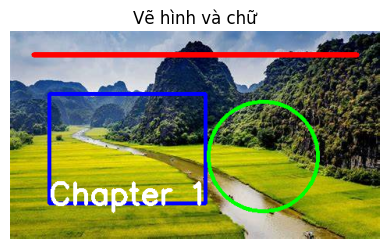

In [6]:
drawn = image_bgr.copy()
cv2.line(drawn, (30, 30), (width - 30, 30), (0, 0, 255), 5)
cv2.rectangle(drawn, (50, 80), (250, 220), (255, 0, 0), 4)
cv2.circle(drawn, (width - 150, 160), 70, (0, 255, 0), 4)
cv2.putText(drawn, 'Chapter 1', (50, height - 45),
            cv2.FONT_HERSHEY_SIMPLEX, 1.3, (255, 255, 255), 3)

cv2.imwrite(str(OUTPUT_DIR / 'cau_5_ve_hinh_va_text.png'), drawn)
show_images([('Vẽ hình và chữ', cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))])
